# Guidance Model Evaluation

Use this notebook to evaluate a trained guidance model on a held-out polygon set.

The notebook supports three modes:
- **Fresh synthetic test set**: set `GENERATE_FRESH_TEST_SET = True` and the notebook will generate a brand-new polygon test set in memory with a new RNG seed.
- **External test file**: set `TEST_DATA_PATH` to a separate `.npz` and the notebook will treat that entire file as the held-out set.
- **Deterministic proxy split**: leave `TEST_DATA_PATH = None` and the notebook will carve out a reproducible test split from the checkpoint's `training_data_path`.

Important caveat:
- The proxy split is only a *true* held-out test if the checkpoint was trained without those indices.
- The current guidance training script does not persist train/test split indices, so if your checkpoint was trained on the full dataset then the proxy split is only a convenience estimate, not a leak-free benchmark.

What this notebook measures:
- Random-timestep evaluation, which matches the guidance model's training distribution.
- A timestep sweep, so you can see whether the model is only reliable at low noise or stays useful deeper into the diffusion chain.
- Task-specific diagnostics for either classifier or regressor guidance.

In [12]:
import importlib
import sys
from pathlib import Path


def ensure_repo_on_path() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "pyproject.toml").exists() and (root / "polydiff").is_dir():
            root_str = str(root)
            if root_str not in sys.path:
                sys.path.insert(0, root_str)
            return root
    raise RuntimeError(
        "Could not locate repo root. Start Jupyter from this repo or install with: pip install -e .[dev]"
    )


REPO_ROOT = ensure_repo_on_path()

mod = sys.modules.get("polydiff")
if mod is not None:
    mod_file = Path(getattr(mod, "__file__", "") or "")
    if not mod_file.exists() or REPO_ROOT not in mod_file.parents:
        del sys.modules["polydiff"]

polydiff = importlib.import_module("polydiff")
print(f"repo root: {REPO_ROOT}")
print(f"polydiff module: {getattr(polydiff, '__file__', 'unknown')}")


repo root: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff
polydiff module: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/polydiff/__init__.py


In [13]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from polydiff import paths
from polydiff.data import gen_polygons
from polydiff.data.gen_polygons import regularity_score
from polydiff.models.diffusion import Diffusion, DiffusionConfig
from polydiff.models.guidance_models import build_guidance_model

plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:,.4f}".format


In [14]:
CHECKPOINT_PATH = paths.PROJECT_ROOT / "models" / "classifier_final.pt"
TEST_DATA_PATH = None  # set this to a separate .npz for a true held-out test file
GENERATE_FRESH_TEST_SET = True  # if True, ignore TEST_DATA_PATH and generate a brand-new synthetic test set
GENERATED_TEST_NUM_SAMPLES = 2000
GENERATED_TEST_SEED = 12345
GENERATED_TEST_DEFORM_DIST = "beta"
GENERATED_TEST_REJECT_SELF_INTERSECTIONS = True
GENERATED_TEST_RADIAL_SIGMA = 0.18
GENERATED_TEST_ANGLE_SIGMA = 0.12
GENERATED_TEST_SMOOTH_PASSES = 3
TEST_FRACTION = 0.20  # only used when TEST_DATA_PATH is None
SPLIT_SEED = 0
MAX_TEST_SAMPLES = None  # set to an int to speed up evaluation on very large test sets
BATCH_SIZE = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_TIME_EVAL_REPEATS = 1
TIMESTEP_FRACTION_GRID = np.linspace(0.0, 0.95, 10)
NOISE_REPEATS_PER_TIMESTEP = 3

print(f"checkpoint path: {CHECKPOINT_PATH}")
print(f"device: {DEVICE}")
print(f"generate fresh test set: {GENERATE_FRESH_TEST_SET}")


checkpoint path: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/models/classifier_final.pt
device: cpu
generate fresh test set: True


In [15]:
class _ScheduleOnlyDenoiser(nn.Module):
    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        raise RuntimeError("_ScheduleOnlyDenoiser.forward should never be called")


def resolve_project_path(path_like: str | Path) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        return paths.PROJECT_ROOT / path
    return path


def load_guidance_checkpoint(checkpoint_path: str | Path) -> dict[str, object]:
    checkpoint_path = resolve_project_path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if "model_state" not in checkpoint:
        raise ValueError(f"Checkpoint at {checkpoint_path} does not look like a guidance-model checkpoint")
    return checkpoint


def load_polygon_npz(data_path: str | Path) -> dict[str, object]:
    data_path = resolve_project_path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Missing polygon dataset: {data_path}")

    npz_data = np.load(data_path, allow_pickle=True)
    coords = np.asarray(npz_data["coords"], dtype=np.float32)
    n_vertices = int(npz_data["n"]) if "n" in npz_data else int(coords.shape[1])
    if "score" in npz_data:
        scores = np.asarray(npz_data["score"], dtype=np.float32)
    else:
        scores = np.asarray([regularity_score(xy).score for xy in coords], dtype=np.float32)

    return {
        "data_path": data_path,
        "coords": coords,
        "x": coords.reshape(coords.shape[0], -1),
        "scores": scores,
        "n_vertices": n_vertices,
    }


def build_targets_from_checkpoint(scores: np.ndarray, checkpoint: dict[str, object]) -> tuple[np.ndarray, dict[str, object]]:
    task = str(checkpoint.get("guidance_task", "classifier")).lower()
    if task == "classifier":
        label_info = dict(checkpoint.get("label_info", {}))
        threshold = float(label_info.get("threshold", 0.8))
        positive_class = int(label_info.get("positive_class", 1))
        targets = (scores >= threshold).astype(np.int64)
        info = {
            "task": "classifier",
            "threshold": threshold,
            "positive_class": positive_class,
        }
        return targets, info

    if task == "regressor":
        info = {
            "task": "regressor",
            "metric": dict(checkpoint.get("target_info", {})).get("metric", "regularity_score"),
        }
        return scores.astype(np.float32), info

    raise ValueError(f"Unsupported guidance_task {task!r}; expected one of: classifier, regressor")


def build_model_from_checkpoint(checkpoint: dict[str, object], device: torch.device) -> torch.nn.Module:
    task = str(checkpoint.get("guidance_task", "classifier")).lower()
    n_vertices = int(checkpoint.get("n_vertices", 6))
    model_cfg = dict(checkpoint.get("model_cfg", {}))
    model_cfg.setdefault("type", "mlp")
    num_classes = int(checkpoint.get("num_classes", 2))

    model = build_guidance_model(
        task=task,
        data_dim=n_vertices * 2,
        model_cfg=model_cfg,
        num_classes=max(2, num_classes),
    )
    model.load_state_dict(checkpoint["model_state"])
    model.to(device)
    model.eval()
    return model


def build_forward_diffusion(checkpoint: dict[str, object], device: torch.device) -> Diffusion:
    diffusion_cfg = dict(checkpoint.get("diffusion", {}))
    config = DiffusionConfig(
        n_steps=int(diffusion_cfg.get("n_steps", 1000)),
        beta_start=float(diffusion_cfg.get("beta_start", 1e-4)),
        beta_end=float(diffusion_cfg.get("beta_end", 2e-2)),
    )
    return Diffusion(model=_ScheduleOnlyDenoiser().to(device), config=config, device=device)


def deterministic_test_indices(num_items: int, test_fraction: float, seed: int) -> np.ndarray:
    if not 0.0 < test_fraction < 1.0:
        raise ValueError(f"test_fraction must be in (0, 1), got {test_fraction}")
    rng = np.random.default_rng(seed)
    indices = np.arange(num_items)
    rng.shuffle(indices)
    n_test = max(1, int(round(num_items * test_fraction)))
    return np.sort(indices[:n_test])


In [16]:
def classifier_metrics_from_frame(
    frame: pd.DataFrame,
    *,
    average_loss: float,
    positive_class: int,
) -> dict[str, float]:
    pred = frame["pred_class"].to_numpy(dtype=np.int64)
    target = frame["target_class"].to_numpy(dtype=np.int64)

    tp = int(((pred == positive_class) & (target == positive_class)).sum())
    fp = int(((pred == positive_class) & (target != positive_class)).sum())
    fn = int(((pred != positive_class) & (target == positive_class)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    if np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0.0:
        f1 = np.nan
    else:
        f1 = 2.0 * precision * recall / (precision + recall)

    return {
        "loss": float(average_loss),
        "accuracy": float((pred == target).mean()),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mean_positive_prob": float(frame["positive_prob"].mean()),
        "target_positive_fraction": float((target == positive_class).mean()),
        "pred_positive_fraction": float((pred == positive_class).mean()),
        "num_examples": int(len(frame)),
    }


def regressor_metrics_from_frame(frame: pd.DataFrame, *, average_loss: float) -> dict[str, float]:
    pred = frame["prediction"].to_numpy(dtype=np.float64)
    target = frame["target_value"].to_numpy(dtype=np.float64)
    residual = pred - target

    if len(pred) > 1 and float(pred.std()) > 0.0 and float(target.std()) > 0.0:
        correlation = float(np.corrcoef(pred, target)[0, 1])
    else:
        correlation = np.nan

    ss_res = float(np.sum((target - pred) ** 2))
    ss_tot = float(np.sum((target - target.mean()) ** 2))
    r2 = np.nan if ss_tot == 0.0 else 1.0 - (ss_res / ss_tot)

    return {
        "loss": float(average_loss),
        "mae": float(np.mean(np.abs(residual))),
        "rmse": float(np.sqrt(np.mean(residual ** 2))),
        "correlation": float(correlation),
        "r2": float(r2),
        "pred_mean": float(pred.mean()),
        "pred_std": float(pred.std()),
        "target_mean": float(target.mean()),
        "target_std": float(target.std()),
        "num_examples": int(len(frame)),
    }


def evaluate_guidance_model(
    model: torch.nn.Module,
    diffusion: Diffusion,
    x_np: np.ndarray,
    targets_np: np.ndarray,
    *,
    task: str,
    batch_size: int,
    device: torch.device,
    sample_ids_np: np.ndarray | None = None,
    local_indices_np: np.ndarray | None = None,
    fixed_t: int | None = None,
    repeats: int = 1,
    positive_class: int = 1,
) -> tuple[dict[str, float], pd.DataFrame]:
    task = str(task).lower()
    num_items = int(x_np.shape[0])
    sample_ids_np = np.arange(num_items) if sample_ids_np is None else np.asarray(sample_ids_np)
    local_indices_np = np.arange(num_items) if local_indices_np is None else np.asarray(local_indices_np)

    rows: list[dict[str, float | int]] = []
    total_loss = 0.0
    total_examples = 0

    model.eval()
    with torch.inference_mode():
        for repeat_idx in range(int(repeats)):
            for start in range(0, num_items, batch_size):
                end = min(start + batch_size, num_items)
                batch_x = torch.from_numpy(x_np[start:end]).to(device=device, dtype=torch.float32)
                batch_n = int(batch_x.shape[0])

                if fixed_t is None:
                    t = torch.randint(0, diffusion.config.n_steps, (batch_n,), device=device, dtype=torch.long)
                else:
                    t = torch.full((batch_n,), int(fixed_t), device=device, dtype=torch.long)

                noise = torch.randn_like(batch_x)
                x_t = diffusion.q_sample(batch_x, t, noise)
                pred = model(x_t, t)

                if task == "classifier":
                    target_batch = torch.from_numpy(targets_np[start:end]).to(device=device, dtype=torch.long)
                    batch_loss = F.cross_entropy(pred, target_batch)
                    probs = torch.softmax(pred, dim=1)
                    pred_class = probs.argmax(dim=1)
                    positive_prob = probs[:, positive_class]

                    for local_idx, sample_id, t_value, target_value, pred_value, prob_value in zip(
                        local_indices_np[start:end],
                        sample_ids_np[start:end],
                        t.detach().cpu().numpy(),
                        target_batch.detach().cpu().numpy(),
                        pred_class.detach().cpu().numpy(),
                        positive_prob.detach().cpu().numpy(),
                    ):
                        rows.append(
                            {
                                "repeat": int(repeat_idx),
                                "local_index": int(local_idx),
                                "sample_id": int(sample_id),
                                "timestep": int(t_value),
                                "target_class": int(target_value),
                                "pred_class": int(pred_value),
                                "positive_prob": float(prob_value),
                            }
                        )
                elif task == "regressor":
                    target_batch = torch.from_numpy(targets_np[start:end]).to(device=device, dtype=torch.float32)
                    pred_flat = pred.reshape(-1)
                    batch_loss = F.mse_loss(pred_flat, target_batch)

                    for local_idx, sample_id, t_value, target_value, pred_value in zip(
                        local_indices_np[start:end],
                        sample_ids_np[start:end],
                        t.detach().cpu().numpy(),
                        target_batch.detach().cpu().numpy(),
                        pred_flat.detach().cpu().numpy(),
                    ):
                        rows.append(
                            {
                                "repeat": int(repeat_idx),
                                "local_index": int(local_idx),
                                "sample_id": int(sample_id),
                                "timestep": int(t_value),
                                "target_value": float(target_value),
                                "prediction": float(pred_value),
                                "residual": float(pred_value - target_value),
                            }
                        )
                else:
                    raise ValueError(f"Unsupported task {task!r}")

                total_loss += float(batch_loss.item()) * batch_n
                total_examples += batch_n

    frame = pd.DataFrame(rows)
    average_loss = total_loss / max(1, total_examples)
    if task == "classifier":
        metrics = classifier_metrics_from_frame(frame, average_loss=average_loss, positive_class=positive_class)
    else:
        metrics = regressor_metrics_from_frame(frame, average_loss=average_loss)

    metrics["repeats"] = int(repeats)
    metrics["fixed_t"] = None if fixed_t is None else int(fixed_t)
    return metrics, frame


def plot_polygon_examples(
    coords: np.ndarray,
    local_indices: list[int],
    titles: list[str],
    *,
    ncols: int = 4,
) -> None:
    if len(local_indices) == 0:
        print("No examples to plot.")
        return

    ncols = min(ncols, len(local_indices))
    nrows = int(math.ceil(len(local_indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for ax in axes.flat:
        ax.axis("off")

    for ax, local_idx, title in zip(axes.flat, local_indices, titles):
        polygon = coords[int(local_idx)]
        closed = np.vstack([polygon, polygon[0]])
        ax.plot(closed[:, 0], closed[:, 1], "-o", lw=2, ms=3)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()


In [17]:
GENERATED_TEST_DATA = None
if GENERATE_FRESH_TEST_SET:
    checkpoint_for_generation = load_guidance_checkpoint(CHECKPOINT_PATH)
    n_vertices_for_generation = int(checkpoint_for_generation.get("n_vertices", 6))
    generated_coords, generated_scores, generated_deform = gen_polygons.batch(
        n=n_vertices_for_generation,
        num=int(GENERATED_TEST_NUM_SAMPLES),
        seed=int(GENERATED_TEST_SEED),
        reject_self_intersections=bool(GENERATED_TEST_REJECT_SELF_INTERSECTIONS),
        deform_dist=str(GENERATED_TEST_DEFORM_DIST),
        radial_sigma=float(GENERATED_TEST_RADIAL_SIGMA),
        angle_sigma=float(GENERATED_TEST_ANGLE_SIGMA),
        smooth_passes=int(GENERATED_TEST_SMOOTH_PASSES),
    )
    GENERATED_TEST_DATA = {
        "data_path": Path(f"generated_test_seed_{GENERATED_TEST_SEED}"),
        "coords": generated_coords,
        "x": generated_coords.reshape(generated_coords.shape[0], -1),
        "scores": generated_scores.astype(np.float32),
        "deform": generated_deform.astype(np.float32),
        "n_vertices": n_vertices_for_generation,
    }
    print(
        f"Generated fresh test set: n={n_vertices_for_generation}, num={GENERATED_TEST_NUM_SAMPLES}, "
        f"seed={GENERATED_TEST_SEED}, deform_dist={GENERATED_TEST_DEFORM_DIST}"
    )
    print(
        "Note: this only matches the training distribution if these generator hyperparameters match the ones used "
        "to build the training data."
    )
else:
    print("Skipping fresh test-set generation. Set GENERATE_FRESH_TEST_SET = True to use a newly generated test set.")


Generated fresh test set: n=6, num=2000, seed=12345, deform_dist=beta
Note: this only matches the training distribution if these generator hyperparameters match the ones used to build the training data.


In [18]:
checkpoint = load_guidance_checkpoint(CHECKPOINT_PATH)
task = str(checkpoint.get("guidance_task", "classifier")).lower()
model = build_model_from_checkpoint(checkpoint, DEVICE)
forward_diffusion = build_forward_diffusion(checkpoint, DEVICE)

checkpoint_data_path = checkpoint.get("training_data_path")
if GENERATED_TEST_DATA is not None:
    source_data = GENERATED_TEST_DATA
    test_indices = np.arange(len(source_data["x"]))
    split_mode = "freshly generated in-notebook test set"
elif TEST_DATA_PATH is None:
    if checkpoint_data_path is None:
        raise ValueError(
            "Checkpoint does not include training_data_path. Set TEST_DATA_PATH explicitly to a held-out .npz file."
        )

    source_data = load_polygon_npz(checkpoint_data_path)
    test_indices = deterministic_test_indices(len(source_data["x"]), TEST_FRACTION, SPLIT_SEED)
    split_mode = "deterministic proxy split from checkpoint training data"
    print(
        "Warning: TEST_DATA_PATH is None, so this uses a deterministic split of the checkpoint training file. "
        "That is only a true held-out evaluation if the checkpoint was trained without these test indices."
    )
else:
    source_data = load_polygon_npz(TEST_DATA_PATH)
    test_indices = np.arange(len(source_data["x"]))
    split_mode = "external held-out test dataset"

if MAX_TEST_SAMPLES is not None:
    test_indices = test_indices[: int(MAX_TEST_SAMPLES)]

if int(source_data["n_vertices"]) != int(checkpoint.get("n_vertices", source_data["n_vertices"])):
    raise ValueError(
        f"Checkpoint expects {int(checkpoint.get('n_vertices'))} vertices, but test data has {int(source_data['n_vertices'])}"
    )

test_coords = source_data["coords"][test_indices]
test_x = source_data["x"][test_indices]
test_scores = source_data["scores"][test_indices]
sample_ids = np.asarray(test_indices, dtype=np.int64)
local_indices = np.arange(len(test_x), dtype=np.int64)
targets_np, target_info = build_targets_from_checkpoint(test_scores, checkpoint)

summary = {
    "checkpoint": str(resolve_project_path(CHECKPOINT_PATH)),
    "task": task,
    "split_mode": split_mode,
    "data_path": str(source_data["data_path"]),
    "n_source_examples": int(len(source_data["x"])),
    "n_test_examples": int(len(test_x)),
    "n_vertices": int(source_data["n_vertices"]),
    "diffusion_steps": int(forward_diffusion.config.n_steps),
    "device": str(DEVICE),
}
if task == "classifier":
    summary["threshold"] = float(target_info["threshold"])
    summary["test_positive_fraction"] = float(targets_np.mean())
else:
    summary["test_score_mean"] = float(targets_np.mean())
    summary["test_score_std"] = float(targets_np.std())

pd.DataFrame([summary])


,checkpoint,task,split_mode,data_path,n_source_examples,n_test_examples,n_vertices,diffusion_steps,device,threshold,test_positive_fraction
0,/Users/jeremyzay/Desktop/thayer_lab_research/2...,classifier,freshly generated in-notebook test set,generated_test_seed_12345,2000,2000,6,20,cpu,0.8000,0.5145


In [19]:
random_metrics, random_eval_df = evaluate_guidance_model(
    model,
    forward_diffusion,
    test_x,
    targets_np,
    task=task,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    sample_ids_np=sample_ids,
    local_indices_np=local_indices,
    fixed_t=None,
    repeats=RANDOM_TIME_EVAL_REPEATS,
    positive_class=int(target_info.get("positive_class", 1)),
)

random_eval_df["score"] = test_scores[random_eval_df["local_index"].to_numpy(dtype=np.int64)]
random_summary_df = pd.DataFrame([random_metrics])
random_summary_df


,loss,accuracy,precision,recall,f1,mean_positive_prob,target_positive_fraction,pred_positive_fraction,num_examples,repeats,fixed_t
0,1.0664,0.4855,NaN,0.0000,NaN,0.1461,0.5145,0.0000,2000,1,None


In [20]:
timestep_values = sorted(
    {
        int(round(float(frac) * max(1, forward_diffusion.config.n_steps - 1)))
        for frac in TIMESTEP_FRACTION_GRID
    }
)

curve_rows: list[dict[str, float]] = []
for t_value in timestep_values:
    metrics, _ = evaluate_guidance_model(
        model,
        forward_diffusion,
        test_x,
        targets_np,
        task=task,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        sample_ids_np=sample_ids,
        local_indices_np=local_indices,
        fixed_t=t_value,
        repeats=NOISE_REPEATS_PER_TIMESTEP,
        positive_class=int(target_info.get("positive_class", 1)),
    )
    metrics["timestep"] = int(t_value)
    metrics["timestep_frac"] = float(t_value / max(1, forward_diffusion.config.n_steps - 1))
    curve_rows.append(metrics)

curve_df = pd.DataFrame(curve_rows)
curve_df


,loss,accuracy,precision,recall,f1,mean_positive_prob,target_positive_fraction,pred_positive_fraction,num_examples,repeats,fixed_t,timestep,timestep_frac
0,1.0664,0.4855,NaN,0.0000,NaN,0.1461,0.5145,0.0000,6000,3,0,0,0.0000
1,1.0664,0.4855,NaN,0.0000,NaN,0.1461,0.5145,0.0000,6000,3,2,2,0.1053
2,1.0657,0.4855,NaN,0.0000,NaN,0.1463,0.5145,0.0000,6000,3,4,4,0.2105
3,1.0660,0.4855,NaN,0.0000,NaN,0.1462,0.5145,0.0000,6000,3,6,6,0.3158
4,1.0662,0.4855,NaN,0.0000,NaN,0.1461,0.5145,0.0000,6000,3,8,8,0.4211
5,1.0661,0.4855,NaN,0.0000,NaN,0.1462,0.5145,0.0000,6000,3,10,10,0.5263
6,1.0663,0.4855,NaN,0.0000,NaN,0.1461,0.5145,0.0000,6000,3,12,12,0.6316
7,1.0668,0.4855,NaN,0.0000,NaN,0.1459,0.5145,0.0000,6000,3,14,14,0.7368
8,1.0669,0.4855,NaN,0.0000,NaN,0.1459,0.5145,0.0000,6000,3,16,16,0.8421
9,1.0674,0.4855,NaN,0.0000,NaN,0.1457,0.5145,0.0000,6000,3,18,18,0.9474


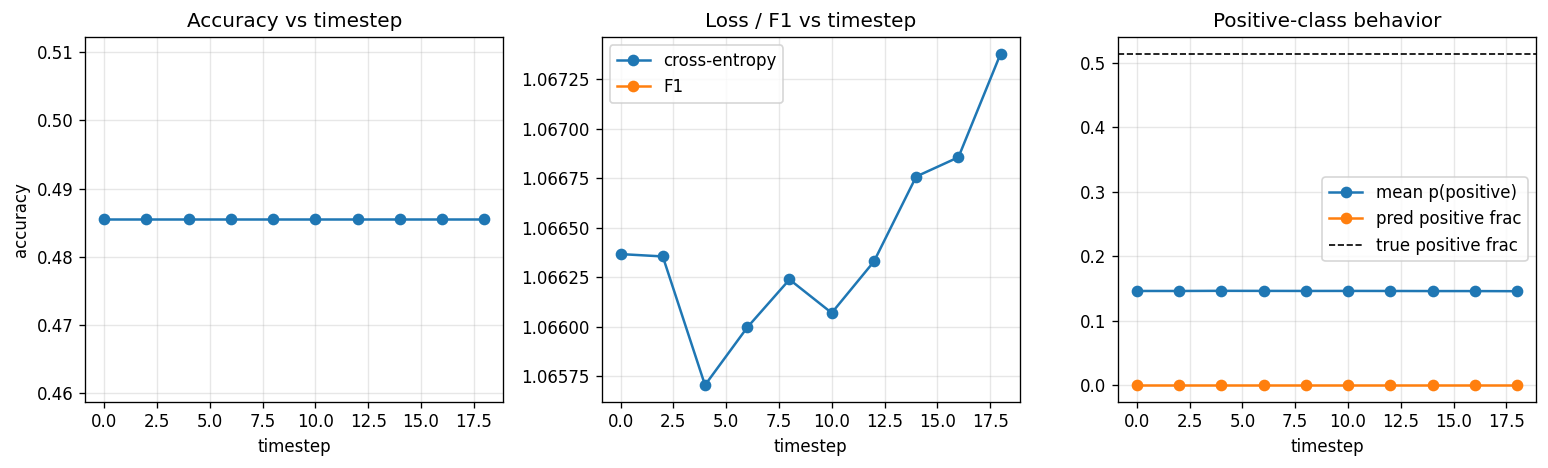

In [21]:
if task == "classifier":
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].plot(curve_df["timestep"], curve_df["accuracy"], marker="o")
    axes[0].set_title("Accuracy vs timestep")
    axes[0].set_xlabel("timestep")
    axes[0].set_ylabel("accuracy")
    axes[0].grid(alpha=0.3)

    axes[1].plot(curve_df["timestep"], curve_df["loss"], marker="o", label="cross-entropy")
    axes[1].plot(curve_df["timestep"], curve_df["f1"], marker="o", label="F1")
    axes[1].set_title("Loss / F1 vs timestep")
    axes[1].set_xlabel("timestep")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    axes[2].plot(curve_df["timestep"], curve_df["mean_positive_prob"], marker="o", label="mean p(positive)")
    axes[2].plot(curve_df["timestep"], curve_df["pred_positive_fraction"], marker="o", label="pred positive frac")
    axes[2].axhline(curve_df["target_positive_fraction"].iloc[0], color="black", ls="--", lw=1, label="true positive frac")
    axes[2].set_title("Positive-class behavior")
    axes[2].set_xlabel("timestep")
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
else:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].plot(curve_df["timestep"], curve_df["mae"], marker="o")
    axes[0].set_title("MAE vs timestep")
    axes[0].set_xlabel("timestep")
    axes[0].set_ylabel("MAE")
    axes[0].grid(alpha=0.3)

    axes[1].plot(curve_df["timestep"], curve_df["correlation"], marker="o")
    axes[1].set_title("Correlation vs timestep")
    axes[1].set_xlabel("timestep")
    axes[1].set_ylabel("corr(pred, target)")
    axes[1].grid(alpha=0.3)

    axes[2].plot(curve_df["timestep"], curve_df["r2"], marker="o")
    axes[2].set_title("R^2 vs timestep")
    axes[2].set_xlabel("timestep")
    axes[2].set_ylabel("R^2")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()


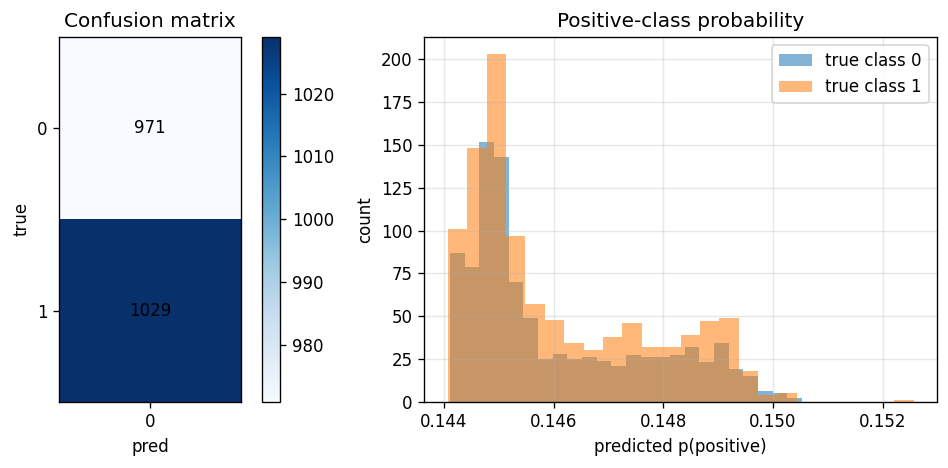

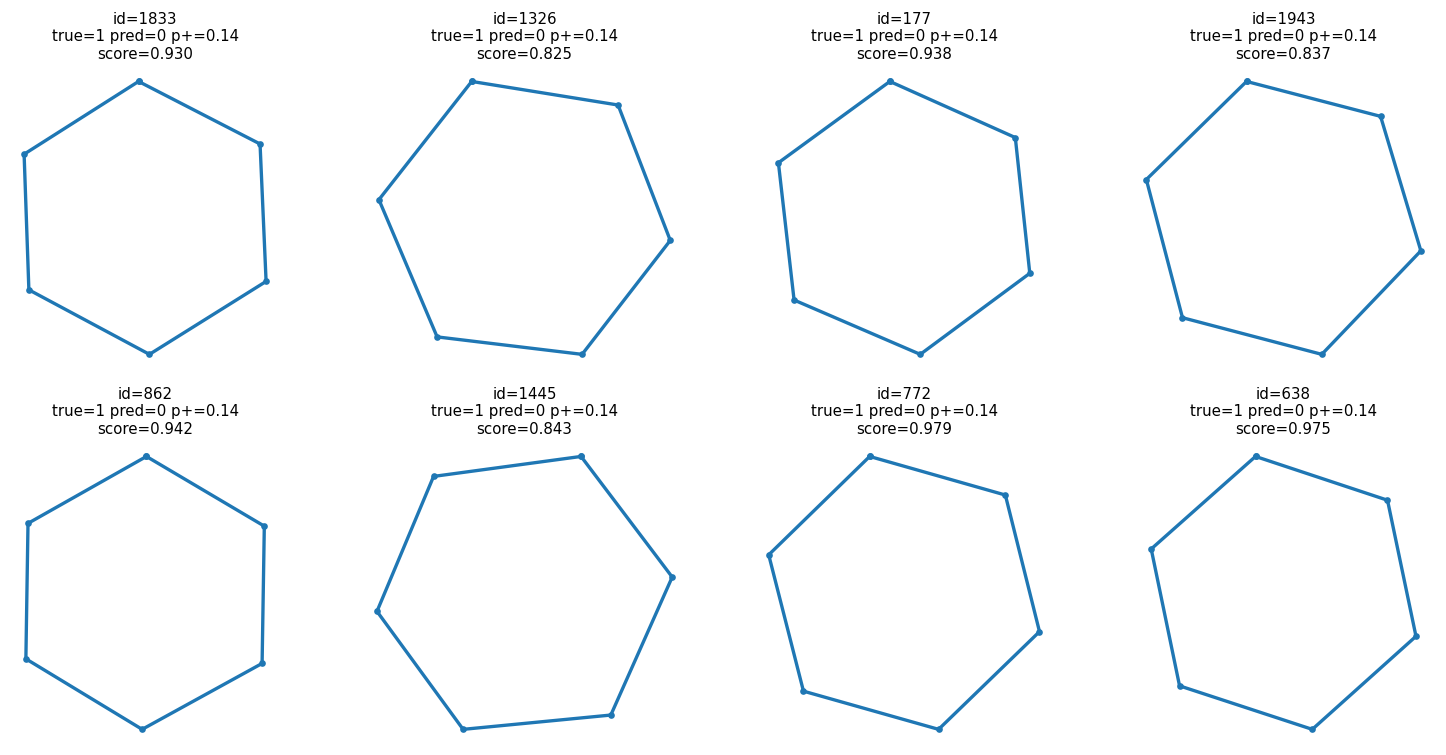

In [22]:
if task == "classifier":
    cm = pd.crosstab(
        random_eval_df["target_class"],
        random_eval_df["pred_class"],
        rownames=["true"],
        colnames=["pred"],
        dropna=False,
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    image = axes[0].imshow(cm.to_numpy(), cmap="Blues")
    axes[0].set_title("Confusion matrix")
    axes[0].set_xlabel("pred")
    axes[0].set_ylabel("true")
    axes[0].set_xticks(range(cm.shape[1]))
    axes[0].set_xticklabels(cm.columns.tolist())
    axes[0].set_yticks(range(cm.shape[0]))
    axes[0].set_yticklabels(cm.index.tolist())
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, int(cm.iloc[i, j]), ha="center", va="center", color="black")
    fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

    positive_class = int(target_info.get("positive_class", 1))
    for target_class, color in [(0, "tab:blue"), (positive_class, "tab:orange")]:
        subset = random_eval_df[random_eval_df["target_class"] == target_class]
        if len(subset) > 0:
            axes[1].hist(subset["positive_prob"], bins=24, alpha=0.55, label=f"true class {target_class}", color=color)
    axes[1].set_title("Positive-class probability")
    axes[1].set_xlabel("predicted p(positive)")
    axes[1].set_ylabel("count")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()

    mistakes = random_eval_df[random_eval_df["pred_class"] != random_eval_df["target_class"]].copy()
    if len(mistakes) == 0:
        print("No misclassified held-out examples in the random-timestep pass.")
    else:
        mistakes["confidence"] = np.where(
            mistakes["pred_class"] == positive_class,
            mistakes["positive_prob"],
            1.0 - mistakes["positive_prob"],
        )
        worst = mistakes.sort_values("confidence", ascending=False).head(8)
        titles = [
            f"id={int(row.sample_id)}\ntrue={int(row.target_class)} pred={int(row.pred_class)} p+={float(row.positive_prob):.2f}\nscore={float(row.score):.3f}"
            for row in worst.itertuples(index=False)
        ]
        plot_polygon_examples(test_coords, worst["local_index"].astype(int).tolist(), titles)

    cm
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(random_eval_df["target_value"], random_eval_df["prediction"], s=12, alpha=0.55)
    lo = min(float(random_eval_df["target_value"].min()), float(random_eval_df["prediction"].min()))
    hi = max(float(random_eval_df["target_value"].max()), float(random_eval_df["prediction"].max()))
    axes[0].plot([lo, hi], [lo, hi], color="black", ls="--", lw=1)
    axes[0].set_title("Predicted vs true score")
    axes[0].set_xlabel("true score")
    axes[0].set_ylabel("predicted score")
    axes[0].grid(alpha=0.3)

    axes[1].hist(random_eval_df["residual"], bins=30, alpha=0.8)
    axes[1].set_title("Residual distribution")
    axes[1].set_xlabel("prediction - true")
    axes[1].set_ylabel("count")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()

    worst = random_eval_df.iloc[np.argsort(np.abs(random_eval_df["residual"].to_numpy()))[::-1][:8]].copy()
    titles = [
        f"id={int(row.sample_id)}\ntrue={float(row.target_value):.3f} pred={float(row.prediction):.3f}\nresidual={float(row.residual):+.3f}"
        for row in worst.itertuples(index=False)
    ]
    plot_polygon_examples(test_coords, worst["local_index"].astype(int).tolist(), titles)

    random_eval_df.head()
